<a href="https://colab.research.google.com/github/batoolabualhayjaa33-droid/ML-final-project/blob/main/OnlineNewsPopularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats_module
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [42]:
news_data = pd.read_csv("OnlineNewsPopularity.csv")

display(news_data.head())

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [43]:
news_data.columns = news_data.columns.str.strip()

In [44]:
print(news_data.shape)

(39644, 61)


In [45]:
print(news_data.columns)

Index(['url', 'timedelta', 'n_tokens_title', 'n_tokens_content',
       'n_unique_tokens', 'n_non_stop_words', 'n_non_stop_unique_tokens',
       'num_hrefs', 'num_self_hrefs', 'num_imgs', 'num_videos',
       'average_token_length', 'num_keywords', 'data_channel_is_lifestyle',
       'data_channel_is_entertainment', 'data_channel_is_bus',
       'data_channel_is_socmed', 'data_channel_is_tech',
       'data_channel_is_world', 'kw_min_min', 'kw_max_min', 'kw_avg_min',
       'kw_min_max', 'kw_max_max', 'kw_avg_max', 'kw_min_avg', 'kw_max_avg',
       'kw_avg_avg', 'self_reference_min_shares', 'self_reference_max_shares',
       'self_reference_avg_sharess', 'weekday_is_monday', 'weekday_is_tuesday',
       'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday',
       'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend', 'LDA_00',
       'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04', 'global_subjectivity',
       'global_sentiment_polarity', 'global_rate_positive_words',
     

In [46]:
news_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 61 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url                            39644 non-null  object 
 1   timedelta                      39644 non-null  float64
 2   n_tokens_title                 39644 non-null  float64
 3   n_tokens_content               39644 non-null  float64
 4   n_unique_tokens                39644 non-null  float64
 5   n_non_stop_words               39644 non-null  float64
 6   n_non_stop_unique_tokens       39644 non-null  float64
 7   num_hrefs                      39644 non-null  float64
 8   num_self_hrefs                 39644 non-null  float64
 9   num_imgs                       39644 non-null  float64
 10  num_videos                     39644 non-null  float64
 11  average_token_length           39644 non-null  float64
 12  num_keywords                   39644 non-null 

In [47]:
display(news_data.describe())

,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
count,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,...,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000,39644.000000
mean,354.530471,10.398749,546.514731,0.548216,0.996469,0.689175,10.883690,3.293638,4.544143,1.249874,...,0.095446,0.756728,-0.259524,-0.521944,-0.107500,0.282353,0.071425,0.341843,0.156064,3395.380184
std,214.163767,2.114037,471.107508,3.520708,5.231231,3.264816,11.332017,3.855141,8.309434,4.107855,...,0.071315,0.247786,0.127726,0.290290,0.095373,0.324247,0.265450,0.188791,0.226294,11626.950749
min,8.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000
25%,164.000000,9.000000,246.000000,0.470870,1.000000,0.625739,4.000000,1.000000,1.000000,0.000000,...,0.050000,0.600000,-0.328383,-0.700000,-0.125000,0.000000,0.000000,0.166667,0.000000,946.000000
50%,339.000000,10.000000,409.000000,0.539226,1.000000,0.690476,8.000000,3.000000,1.000000,0.000000,...,0.100000,0.800000,-0.253333,-0.500000,-0.100000,0.150000,0.000000,0.500000,0.000000,1400.000000
75%,542.000000,12.000000,716.000000,0.608696,1.000000,0.754630,14.000000,4.000000,4.000000,1.000000,...,0.100000,1.000000,-0.186905,-0.300000,-0.050000,0.500000,0.150000,0.500000,0.250000,2800.000000
max,731.000000,23.000000,8474.000000,701.000000,1042.000000,650.000000,304.000000,116.000000,128.000000,91.000000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.500000,1.000000,843300.000000


In [48]:
missing_values = news_data.isnull().sum()

print(missing_values)

url                             0
timedelta                       0
n_tokens_title                  0
n_tokens_content                0
n_unique_tokens                 0
                               ..
title_subjectivity              0
title_sentiment_polarity        0
abs_title_subjectivity          0
abs_title_sentiment_polarity    0
shares                          0
Length: 61, dtype: int64


In [49]:
duplicate_rows = news_data.duplicated().sum()

print(duplicate_rows)

0


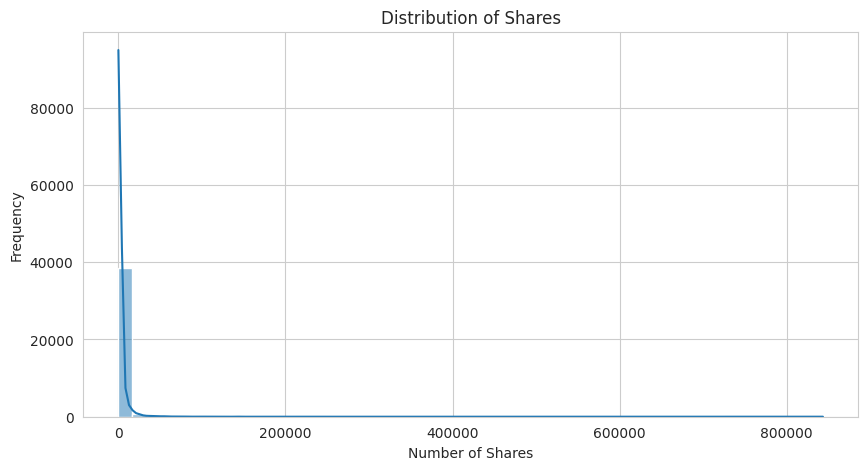

In [50]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(news_data['shares'], bins=50, kde=True)

plt.title("Distribution of Shares")
plt.xlabel("Number of Shares")
plt.ylabel("Frequency")

plt.show()

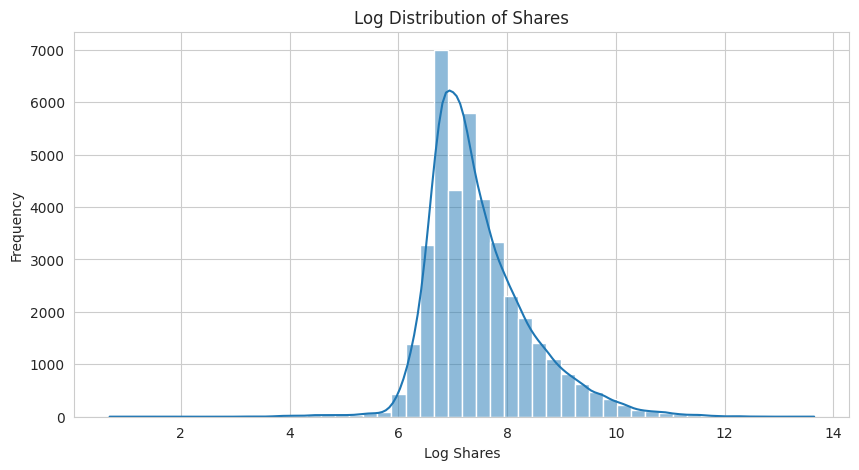

In [51]:
news_data['log_shares'] = np.log1p(news_data['shares'])

plt.figure(figsize=(10,5))

sns.histplot(news_data['log_shares'], bins=50, kde=True)

plt.title("Log Distribution of Shares")
plt.xlabel("Log Shares")
plt.ylabel("Frequency")

plt.show()

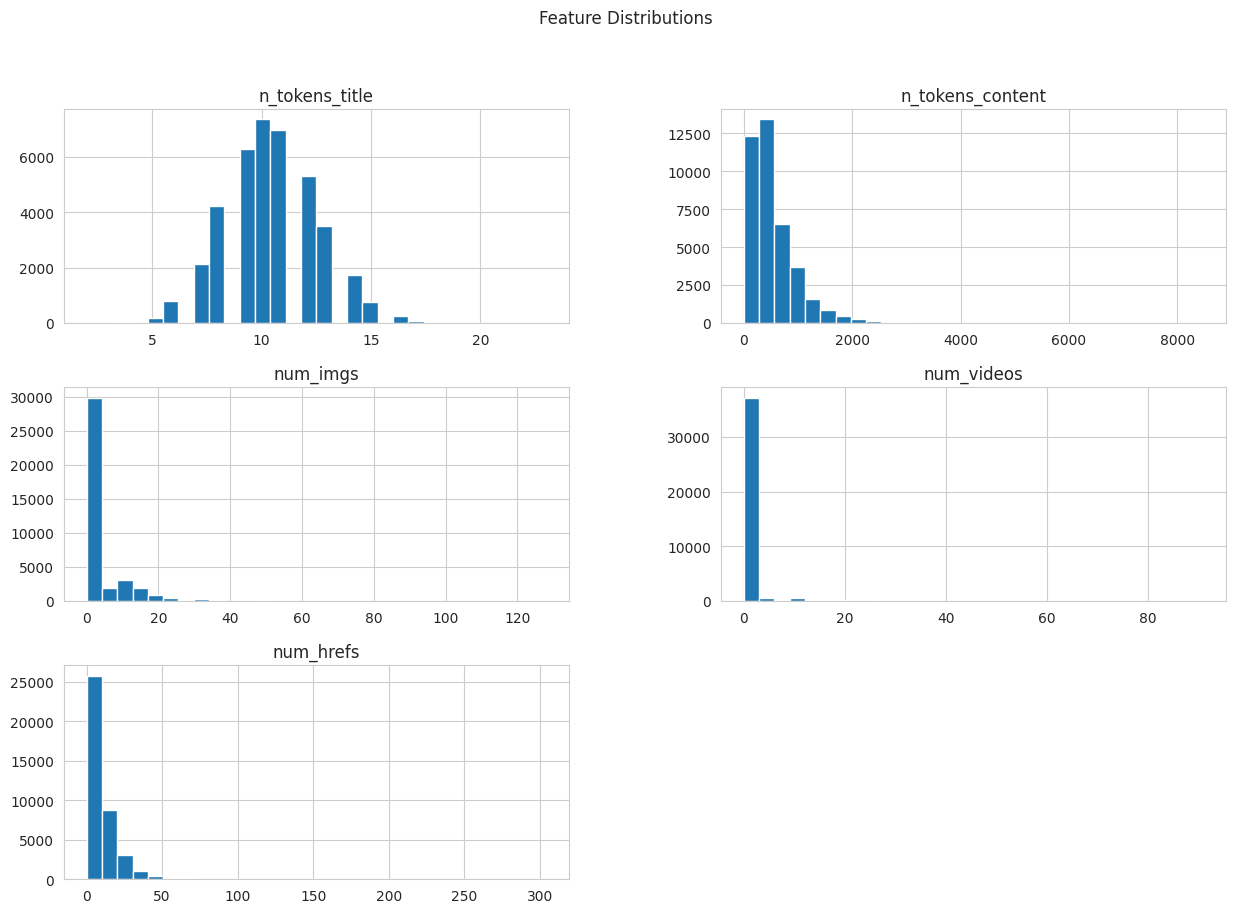

In [52]:
important_features = [
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]

news_data[important_features].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("Feature Distributions")

plt.show()

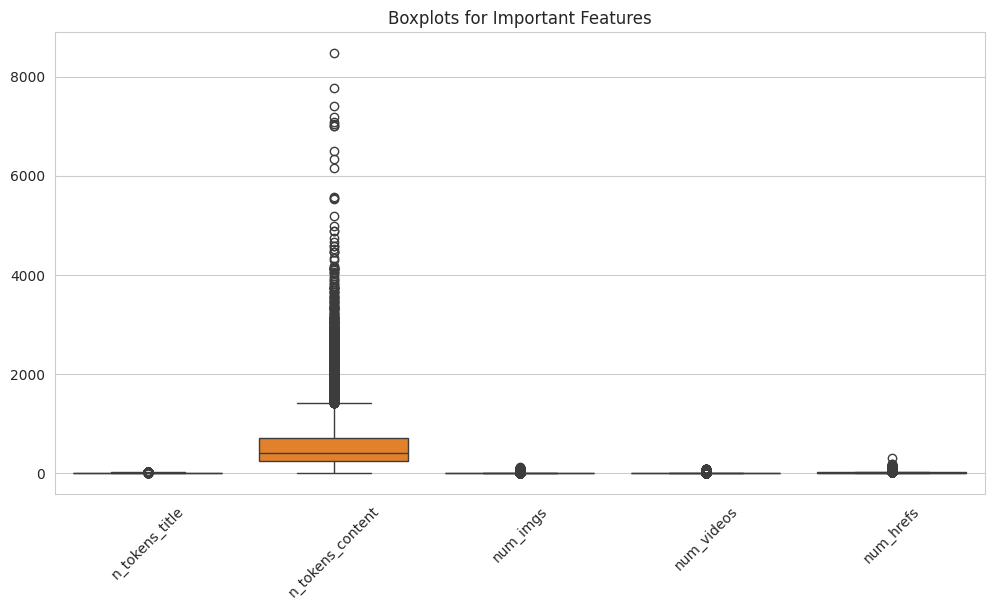

In [53]:
plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[important_features])

plt.title("Boxplots for Important Features")

plt.xticks(rotation=45)

plt.show()

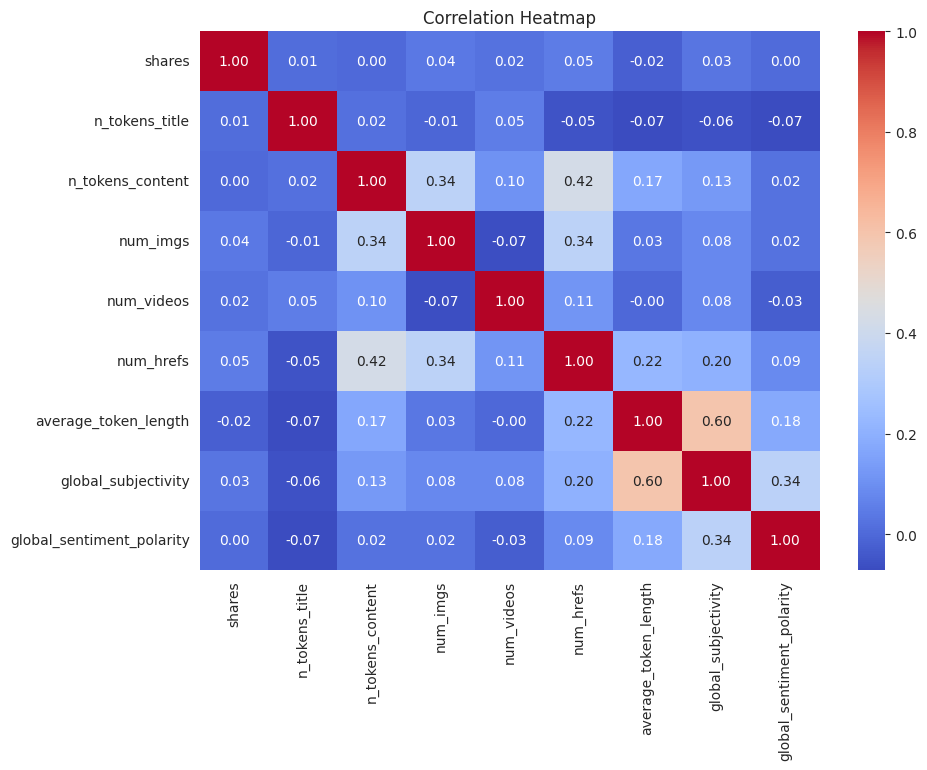

In [54]:
selected_columns = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs',
    'average_token_length',
    'global_subjectivity',
    'global_sentiment_polarity'
]

correlation_matrix = news_data[selected_columns].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

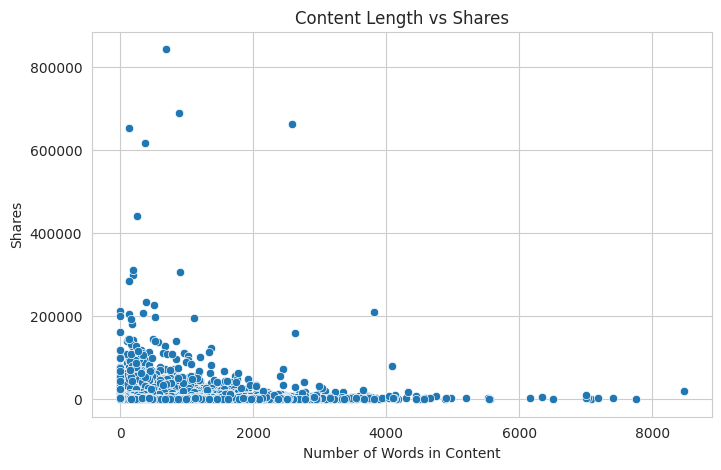

In [55]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['n_tokens_content'],
    y=news_data['shares']
)

plt.title("Content Length vs Shares")
plt.xlabel("Number of Words in Content")
plt.ylabel("Shares")

plt.show()

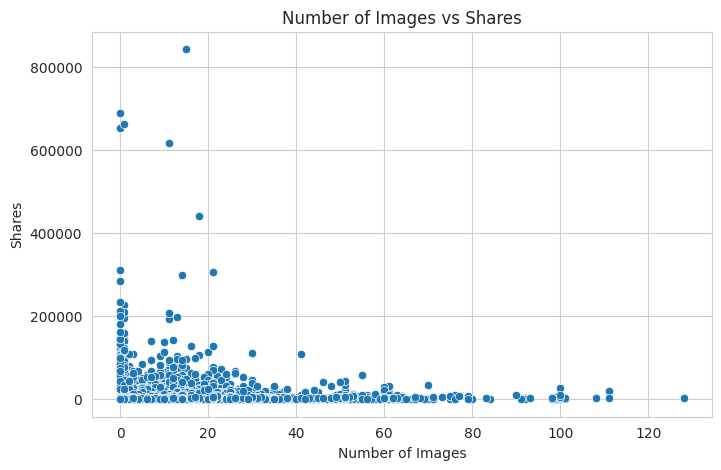

In [56]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['num_imgs'],
    y=news_data['shares']
)

plt.title("Number of Images vs Shares")
plt.xlabel("Number of Images")
plt.ylabel("Shares")

plt.show()

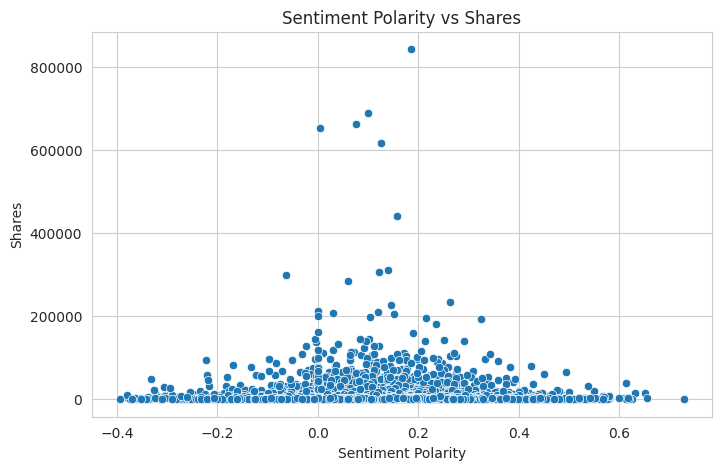

In [57]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=news_data['global_sentiment_polarity'],
    y=news_data['shares']
)

plt.title("Sentiment Polarity vs Shares")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Shares")

plt.show()

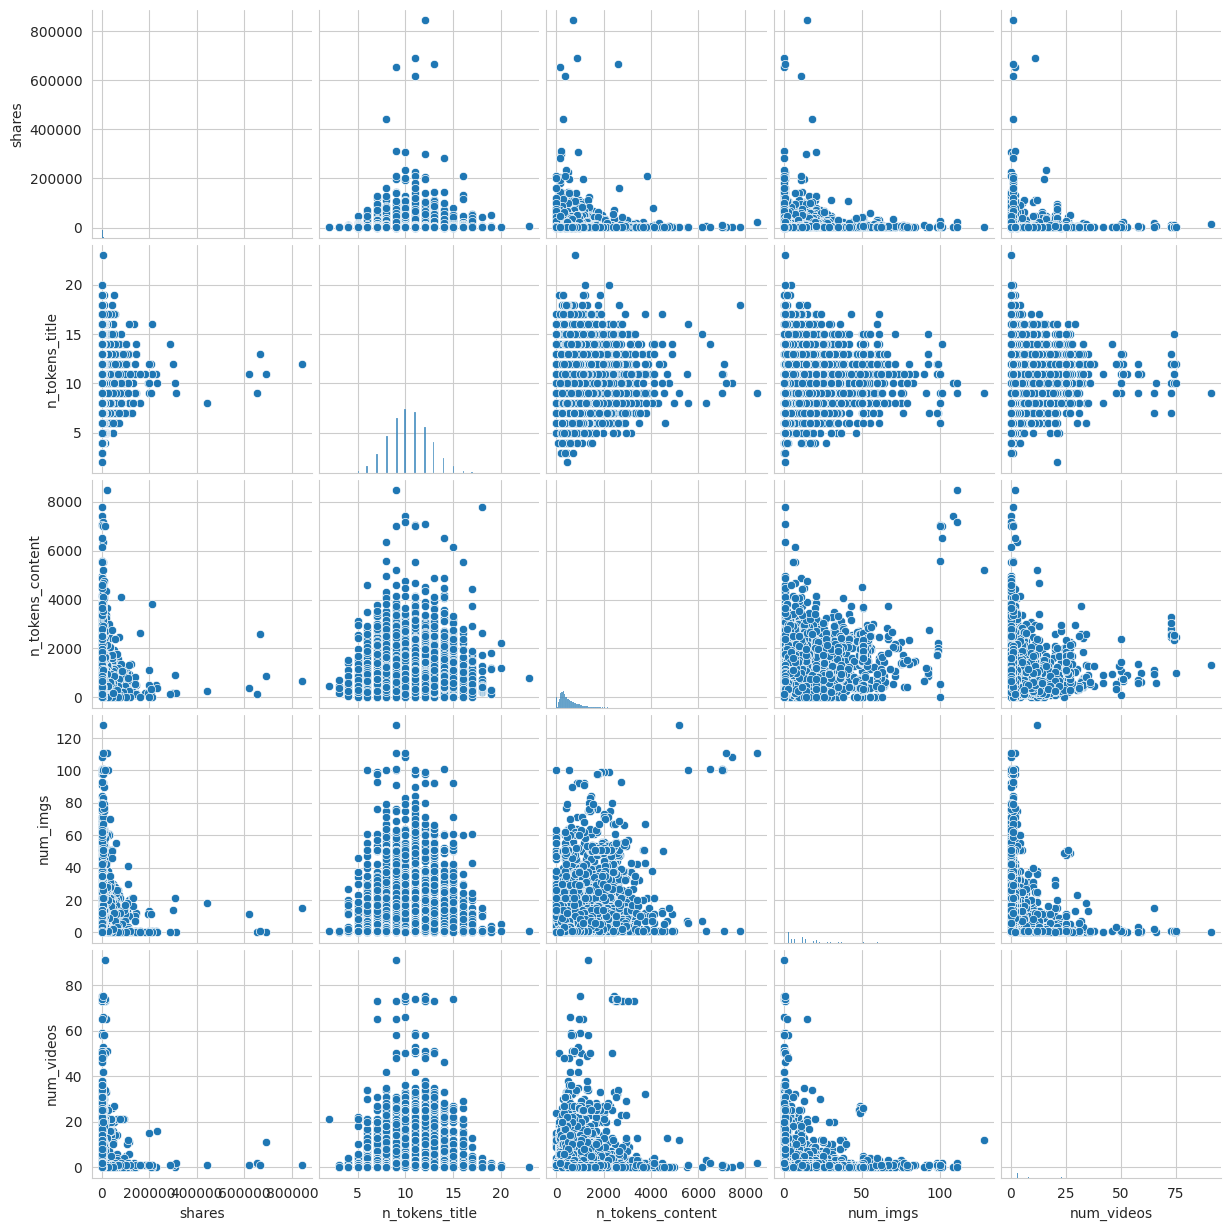

In [58]:
pairplot_features = [
    'shares',
    'n_tokens_title',
    'n_tokens_content',
    'num_imgs',
    'num_videos'
]

sns.pairplot(news_data[pairplot_features])

plt.show()

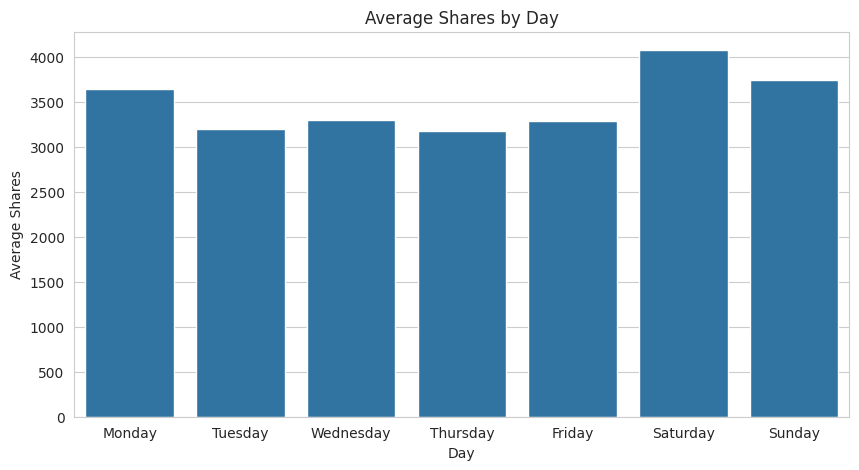

In [59]:
weekday_columns = [
    'weekday_is_monday',
    'weekday_is_tuesday',
    'weekday_is_wednesday',
    'weekday_is_thursday',
    'weekday_is_friday',
    'weekday_is_saturday',
    'weekday_is_sunday'
]



weekday_shares = []

for day in weekday_columns:

    average_shares = news_data[news_data[day] == 1]['shares'].mean()

    weekday_shares.append(average_shares)



days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]



plt.figure(figsize=(10,5))

sns.barplot(
    x=days,
    y=weekday_shares
)

plt.title("Average Shares by Day")
plt.xlabel("Day")
plt.ylabel("Average Shares")

plt.show()



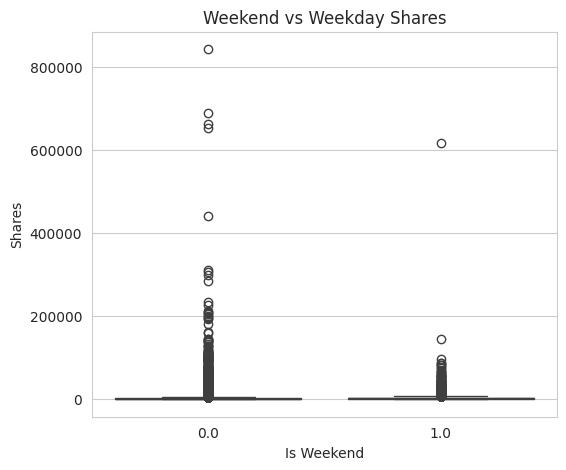

In [60]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x=news_data['is_weekend'],
    y=news_data['shares']
)

plt.title("Weekend vs Weekday Shares")
plt.xlabel("Is Weekend")
plt.ylabel("Shares")

plt.show()

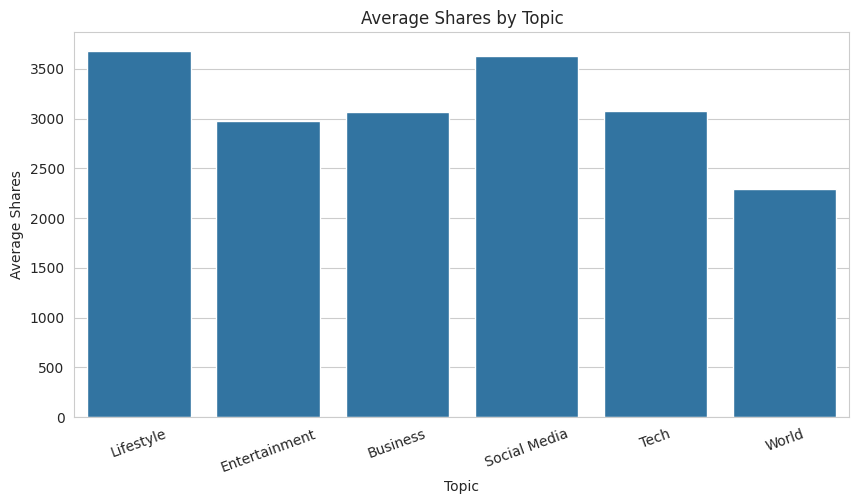

In [61]:
topic_columns = [
    'data_channel_is_lifestyle',
    'data_channel_is_entertainment',
    'data_channel_is_bus',
    'data_channel_is_socmed',
    'data_channel_is_tech',
    'data_channel_is_world'
]

topic_names = [
    'Lifestyle',
    'Entertainment',
    'Business',
    'Social Media',
    'Tech',
    'World'
]

topic_average_shares = []

for topic in topic_columns:

    avg_shares = news_data[news_data[topic] == 1]['shares'].mean()

    topic_average_shares.append(avg_shares)


plt.figure(figsize=(10,5))

sns.barplot(
    x=topic_names,
    y=topic_average_shares
)

plt.title("Average Shares by Topic")
plt.xlabel("Topic")
plt.ylabel("Average Shares")

plt.xticks(rotation=20)

plt.show()

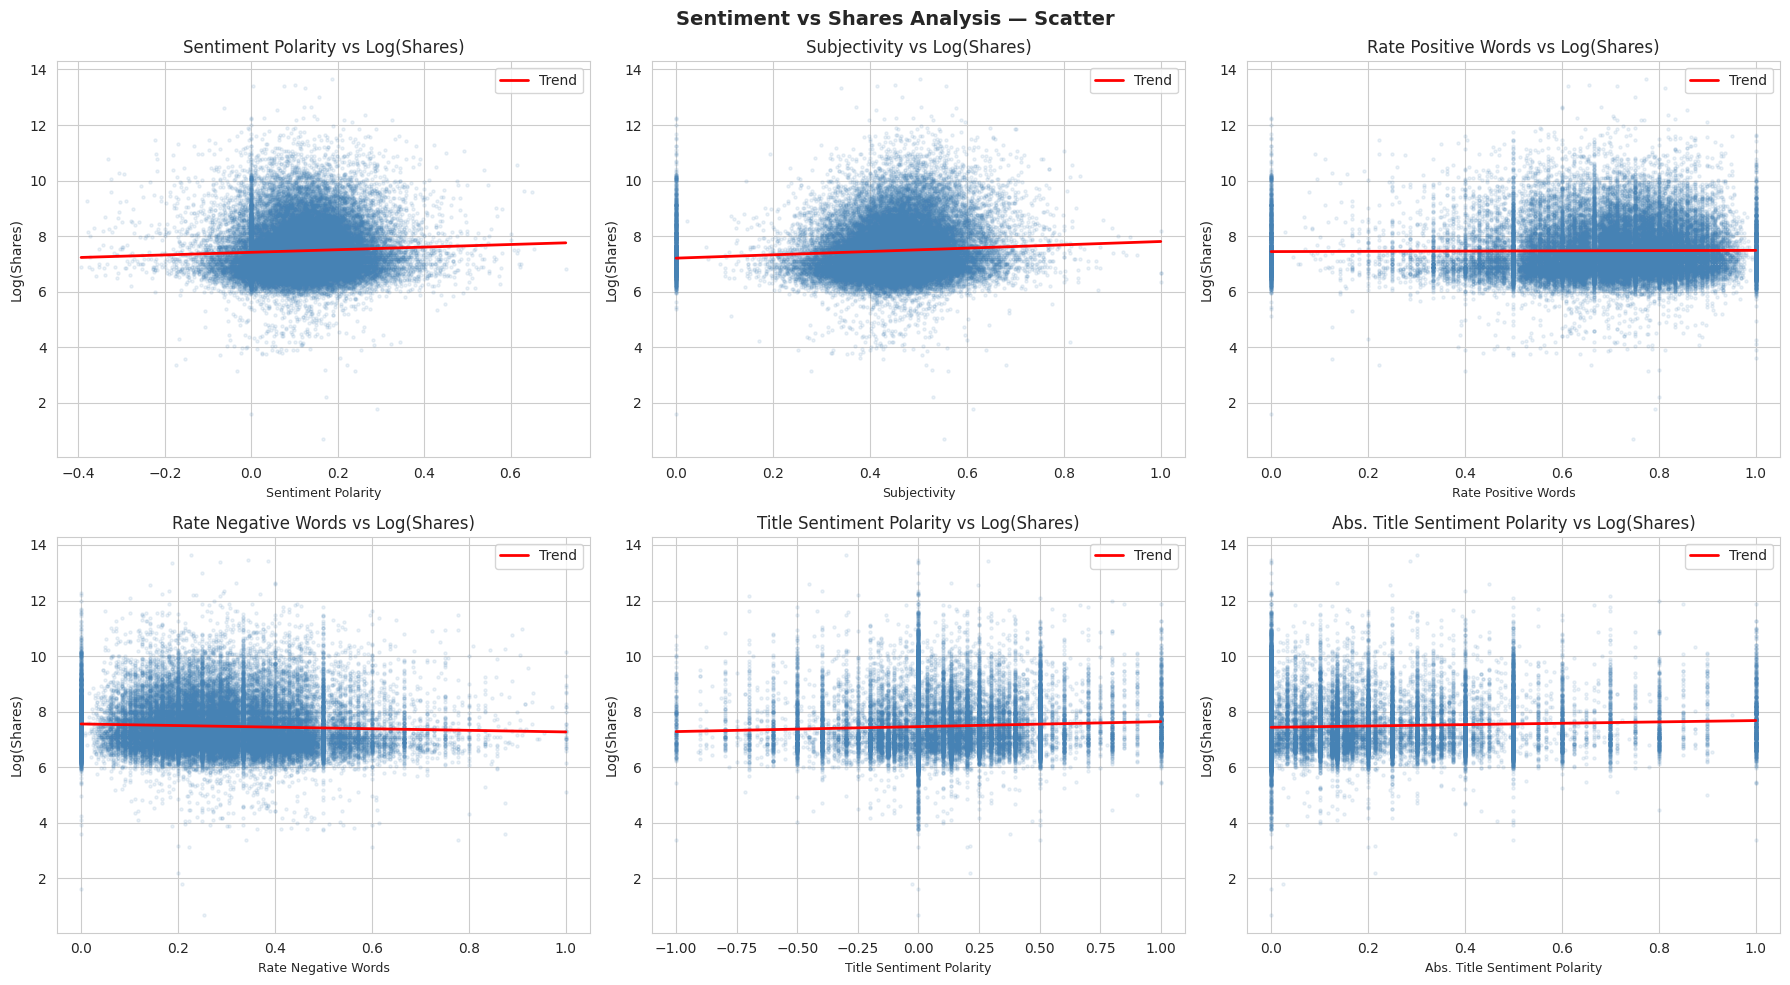

In [62]:
sentiment_features = [
    ('global_sentiment_polarity',    'Sentiment Polarity'),
    ('global_subjectivity',          'Subjectivity'),
    ('rate_positive_words',          'Rate Positive Words'),
    ('rate_negative_words',          'Rate Negative Words'),
    ('title_sentiment_polarity',     'Title Sentiment Polarity'),
    ('abs_title_sentiment_polarity', 'Abs. Title Sentiment Polarity')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (feat, name) in zip(axes.flatten(), sentiment_features):
    # Filter out rows with NaN values in either the current feature or 'shares'
    valid_data_mask = news_data[feat].notna() & news_data['shares'].notna()
    x_for_fit = news_data[feat][valid_data_mask]
    y_for_fit = np.log1p(news_data['shares'][valid_data_mask])

    ax.scatter(x_for_fit, y_for_fit,
               alpha=0.1, color='steelblue', s=5)

    # Perform polyfit only if there are enough valid data points
    if len(x_for_fit) > 1: # np.polyfit requires at least deg + 1 points
        z = np.polyfit(x_for_fit, y_for_fit, 1)
        x_line = np.linspace(x_for_fit.min(), x_for_fit.max(), 100)
        ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2, label='Trend')
    else:
        print(f"Warning: Not enough valid data points for polyfit for feature '{name}'. Skipping trend line.")

    ax.set_xlabel(name, fontsize=9)
    ax.set_ylabel('Log(Shares)')
    ax.set_title(f'{name} vs Log(Shares)')
    ax.legend()

plt.suptitle('Sentiment vs Shares Analysis — Scatter', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6783/2722684874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_popular', y=feat, data=news_s,
/tmp/ipykernel_6783/2722684874.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Popular', 'Popular'])
/tmp/ipykernel_6783/2722684874.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_popular', y=feat, data=news_s,
/tmp/ipykernel_6783/2722684874.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Popular', 'Popular'])
/tmp/ipykernel_6783/27226848

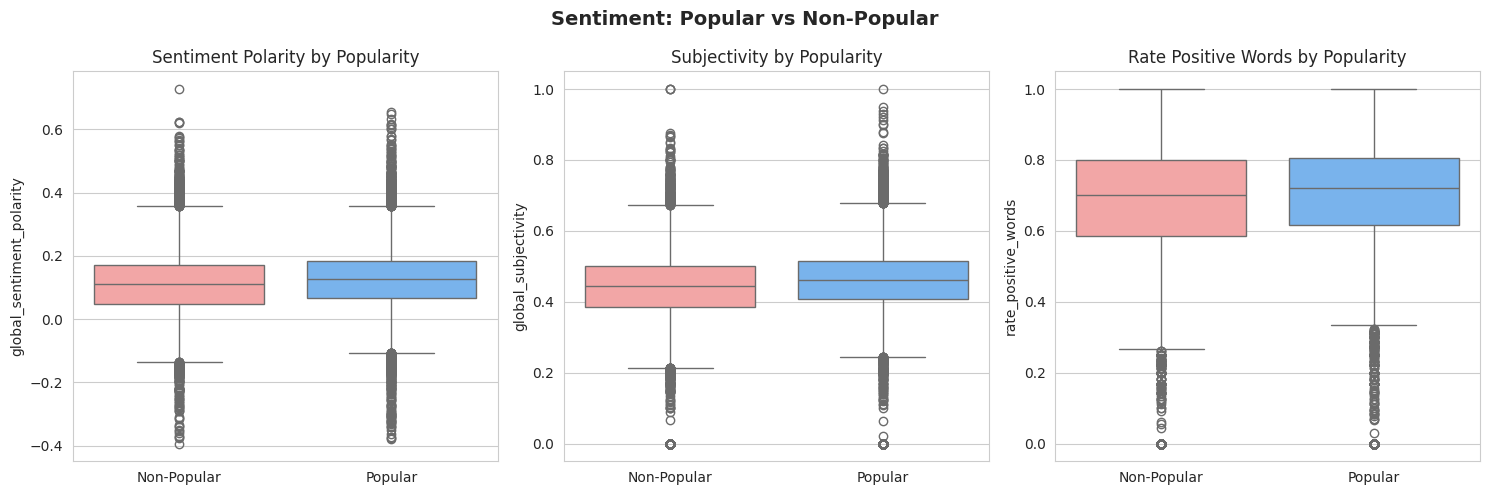

In [63]:
# ─── Sentiment vs Shares — Boxplots by Popularity ───────────────
threshold_sent = news_data['shares'].median()
news_s = news_data.copy()
news_s['is_popular'] = (news_s['shares'] > threshold_sent).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (feat, name) in zip(axes, sentiment_features[:3]):
    sns.boxplot(x='is_popular', y=feat, data=news_s,
                palette=['#ff9999', '#66b3ff'], ax=ax)
    ax.set_xticklabels(['Non-Popular', 'Popular'])
    ax.set_title(f'{name} by Popularity')
    ax.set_xlabel('')

plt.suptitle('Sentiment: Popular vs Non-Popular', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


/tmp/ipykernel_6783/559181140.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(topic_names_pop, rotation=20)


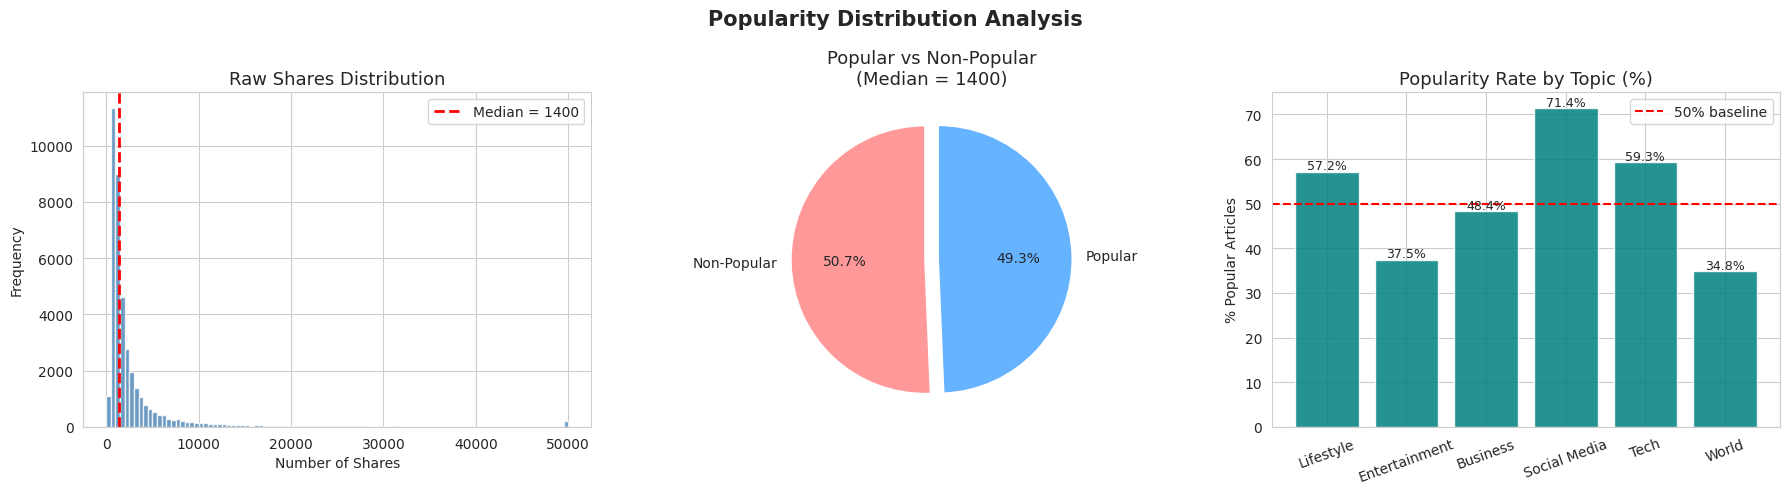

In [64]:
# ─── Popularity Distribution Analysis ───────────────────────────
threshold_pop = news_data['shares'].median()
news_temp = news_data.copy()
news_temp['is_popular'] = (news_temp['shares'] > threshold_pop).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. توزيع الـ Shares مع خط الـ threshold
axes[0].hist(news_temp['shares'].clip(0, 50000), bins=100,
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=threshold_pop, color='red', linestyle='--', linewidth=2,
                label=f'Median = {threshold_pop:.0f}')
axes[0].set_title('Raw Shares Distribution', fontsize=13)
axes[0].set_xlabel('Number of Shares')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# 2. Pie Chart
counts = news_temp['is_popular'].value_counts()
axes[1].pie(
    counts,
    labels=['Non-Popular', 'Popular'],
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'],
    startangle=90,
    explode=(0.05, 0.05)
)
axes[1].set_title(f'Popular vs Non-Popular\n(Median = {threshold_pop:.0f})', fontsize=13)

# 3. Popularity Rate by Topic
topic_cols_pop = [
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus', 'data_channel_is_socmed',
    'data_channel_is_tech', 'data_channel_is_world'
]
topic_names_pop = ['Lifestyle', 'Entertainment', 'Business', 'Social Media', 'Tech', 'World']
rates = [(news_temp[news_temp[c] == 1]['is_popular'].mean() * 100) for c in topic_cols_pop]
bars = axes[2].bar(topic_names_pop, rates, color='teal', edgecolor='white', alpha=0.85)
axes[2].axhline(y=50, color='red', linestyle='--', label='50% baseline')
axes[2].set_title('Popularity Rate by Topic (%)', fontsize=13)
axes[2].set_ylabel('% Popular Articles')
axes[2].set_xticklabels(topic_names_pop, rotation=20)
axes[2].legend()
for bar, val in zip(bars, rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Popularity Distribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


4541
1933
7703
2946
2169


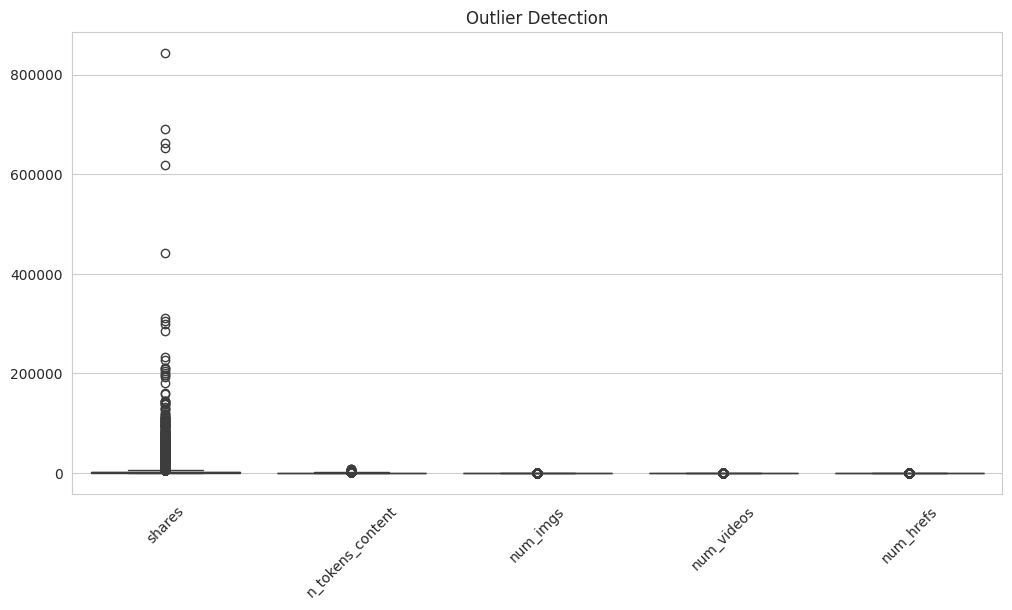

In [65]:

outlier_features = [
    'shares',
    'n_tokens_content',
    'num_imgs',
    'num_videos',
    'num_hrefs'
]



for column in outlier_features:

    Q1 = news_data[column].quantile(0.25)
    Q3 = news_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = news_data[
        (news_data[column] < lower_bound) |
        (news_data[column] > upper_bound)
    ]


    print(outliers.shape[0])



plt.figure(figsize=(12,6))

sns.boxplot(data=news_data[outlier_features])

plt.title("Outlier Detection")

plt.xticks(rotation=45)

plt.show()



clipped_data = news_data.copy()

for column in outlier_features:

    Q1 = clipped_data[column].quantile(0.25)
    Q3 = clipped_data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    clipped_data[column] = clipped_data[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )




In [66]:

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)



scaling_data = news_data.drop(columns=['url'])



standard_scaler = StandardScaler()

standard_scaled_data = standard_scaler.fit_transform(scaling_data)

standard_scaled_data = pd.DataFrame(
    standard_scaled_data,
    columns=scaling_data.columns
)




In [67]:


minmax_scaler = MinMaxScaler()

minmax_scaled_data = minmax_scaler.fit_transform(scaling_data)

minmax_scaled_data = pd.DataFrame(
    minmax_scaled_data,
    columns=scaling_data.columns
)



In [68]:

robust_scaler = RobustScaler()

robust_scaled_data = robust_scaler.fit_transform(scaling_data)

robust_scaled_data = pd.DataFrame(
    robust_scaled_data,
    columns=scaling_data.columns
)



In [69]:
# Feature Engineering
# 1. Content Complexity Score
engineered_data = news_data.copy()
engineered_data['content_complexity'] = (
    engineered_data['average_token_length'] *
    engineered_data['n_tokens_content']
    )

In [70]:
# 2. Keyword Density
engineered_data['keyword_density'] = (
    engineered_data['num_keywords'] /
    (engineered_data['n_tokens_content'] + 1)
)

In [71]:
# 3. Media Score
engineered_data['media_score'] = (
    engineered_data['num_imgs'] +
    engineered_data['num_videos']
)

In [72]:
# 4. Sentiment Engagement Score — Fixed (No Data Leakage)
engineered_data['sentiment_engagement'] = (
    engineered_data['global_sentiment_polarity'] *
    engineered_data['global_subjectivity']
)
print(engineered_data['sentiment_engagement'].describe().round(4))

count    39644.0000
mean         0.0567
std          0.0521
min         -0.3273
25%          0.0238
50%          0.0524
75%          0.0836
max          0.5536
Name: sentiment_engagement, dtype: float64


In [73]:
# 5. Title Length Ratio

engineered_data['title_length_ratio'] = (
    engineered_data['n_tokens_title'] /
    (engineered_data['n_tokens_content'] + 1)
)

In [74]:
# 6. Weekend Feature

engineered_data['weekend_article'] = (
    engineered_data['is_weekend']
)

In [75]:
# 7. Log Transformations

engineered_data['log_shares'] = np.log1p(
    engineered_data['shares']
)

engineered_data['log_content_length'] = np.log1p(
    engineered_data['n_tokens_content']
)


In [76]:
# Display New Features

new_features = [
    'content_complexity',
    'keyword_density',
    'media_score',
    'sentiment_engagement',
    'title_length_ratio',
    'weekend_article',
    'log_shares',
    'log_content_length'
]

print(engineered_data[new_features].head())

   content_complexity  keyword_density  media_score  sentiment_engagement  \
0              1025.0         0.022727          1.0              0.048282   
1              1253.0         0.015625          1.0              0.050828   
2               927.0         0.028302          1.0              0.227052   
3              2339.0         0.013158          1.0              0.043288   
4              5020.0         0.006524         20.0              0.144296   

   title_length_ratio  weekend_article  log_shares  log_content_length  
0            0.054545              0.0    6.386879            5.393628  
1            0.035156              0.0    6.568078            5.545177  
2            0.042453              0.0    7.313887            5.356586  
3            0.016917              0.0    7.090910            6.276643  
4            0.012116              0.0    6.226537            6.978214  
